In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df = pd.read_csv('Karachi 100 Historical Data.csv')


print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      2514 non-null   object
 1   Price     2514 non-null   object
 2   Open      2514 non-null   object
 3   High      2514 non-null   object
 4   Low       2514 non-null   object
 5   Vol.      1318 non-null   object
 6   Change %  2514 non-null   object
dtypes: object(7)
memory usage: 137.6+ KB
None


,Date,Price,Open,High,Low,Vol.,Change %
0,2/20/2026,"173,169.70","172,716.16","174,148.33","169,592.53",245.48M,0.58%
1,2/19/2026,"172,170.30","179,279.73","179,279.73","171,647.34",229.01M,-3.74%
2,2/18/2026,"178,853.09","174,328.61","178,974.17","174,328.61",424.99M,3.29%
3,2/17/2026,"173,150.42","174,783.16","176,131.34","171,693.41",424.96M,-0.75%
4,2/16/2026,"174,453.94","179,926.88","179,969.23","173,574.27",378.71M,-2.87%


In [ ]:
def clean_numeric(val):
    if isinstance(val, str):
        val = val.replace(',', '')
        if 'M' in val:
            return float(val.replace('M', '')) * 1e6
        if 'B' in val:
            return float(val.replace('B', '')) * 1e9
        if 'K' in val:
            return float(val.replace('K', '')) * 1e3
        if '%' in val:
            return float(val.replace('%', ''))
        try:
            return float(val)
        except:
            return None
    return val

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

cols_to_clean = ['Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
for col in cols_to_clean:
    df[col] = df[col].apply(clean_numeric)

df.dropna(subset=['Price', 'Date'], inplace=True)


print(df.info())



<class 'pandas.core.frame.DataFrame'>
Index: 2514 entries, 2513 to 0
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      2514 non-null   datetime64[ns]
 1   Price     2514 non-null   float64       
 2   Open      2514 non-null   float64       
 3   High      2514 non-null   float64       
 4   Low       2514 non-null   float64       
 5   Vol.      1318 non-null   float64       
 6   Change %  2514 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 157.1 KB
None


In [ ]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
2513,2016-01-01,33228.95,32841.49,33256.85,32828.36,73480000.0,1.26
2512,2016-01-04,33009.13,33265.58,33304.40,32968.63,68940000.0,-0.66
2511,2016-01-05,32983.47,32804.32,33027.33,32515.05,99320000.0,-0.08
2510,2016-01-06,32968.26,33036.63,33123.53,32930.37,61270000.0,-0.05
2509,2016-01-07,32682.50,32964.65,32964.65,32652.39,79280000.0,-0.87


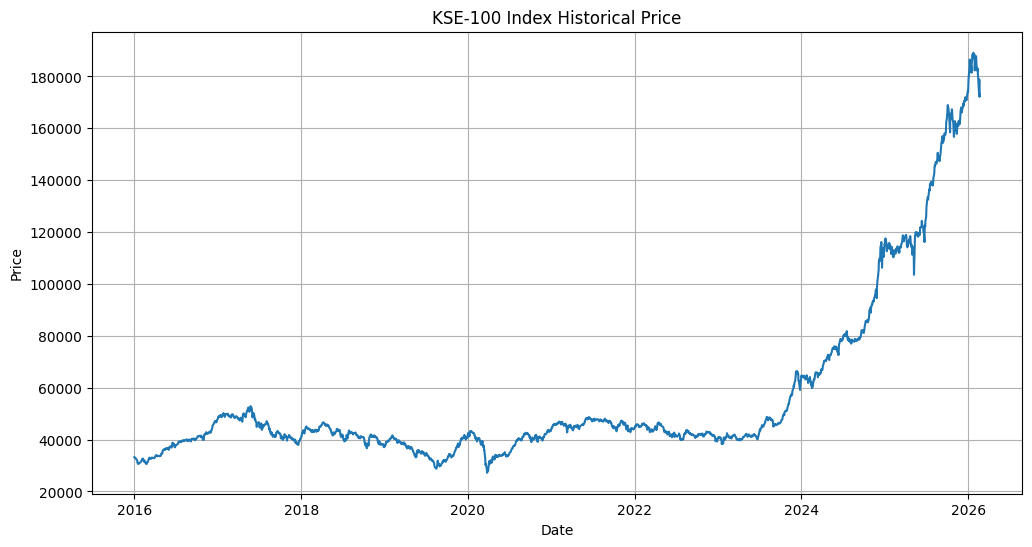

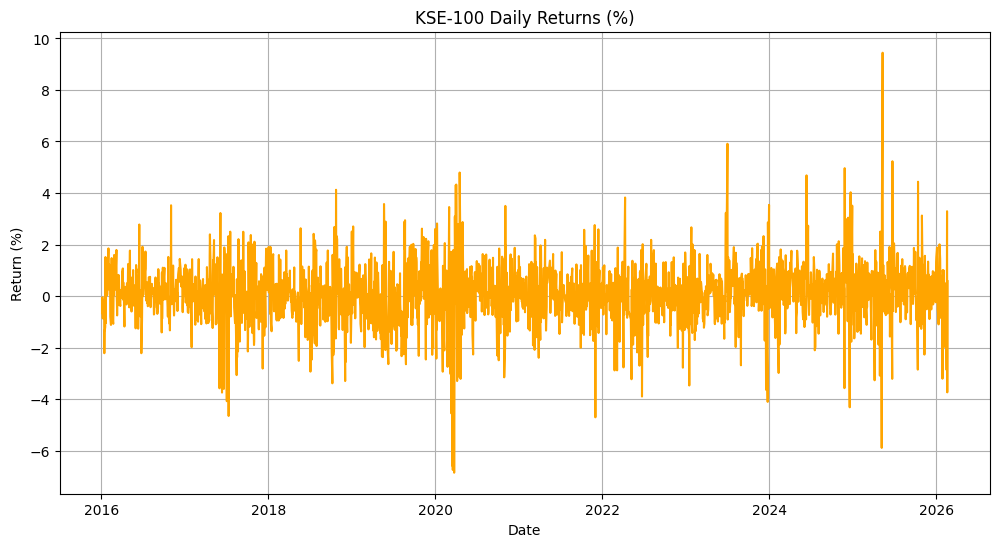


ADF Statistic: 2.5343378198185835
p-value: 0.9990600931991294
Critical Value (1%): -3.4329789374204935
Critical Value (5%): -2.8627014485379787
Critical Value (10%): -2.5673882843825098


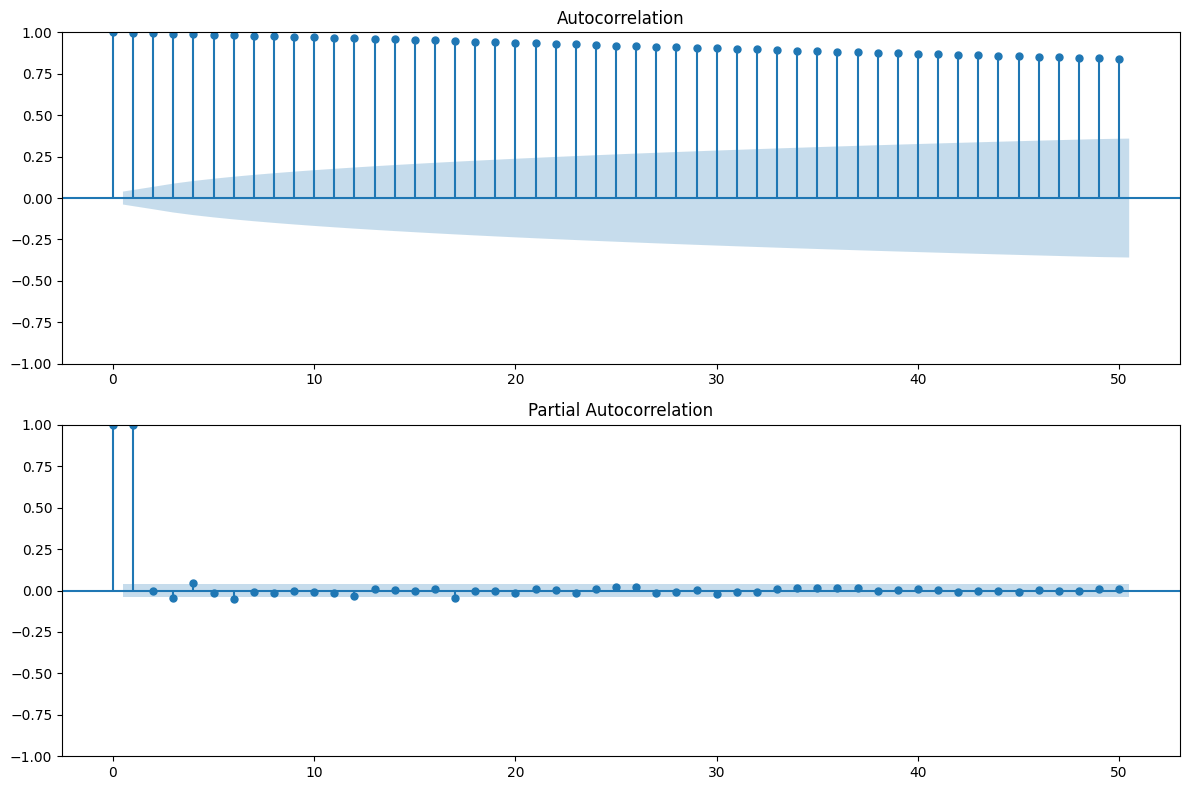

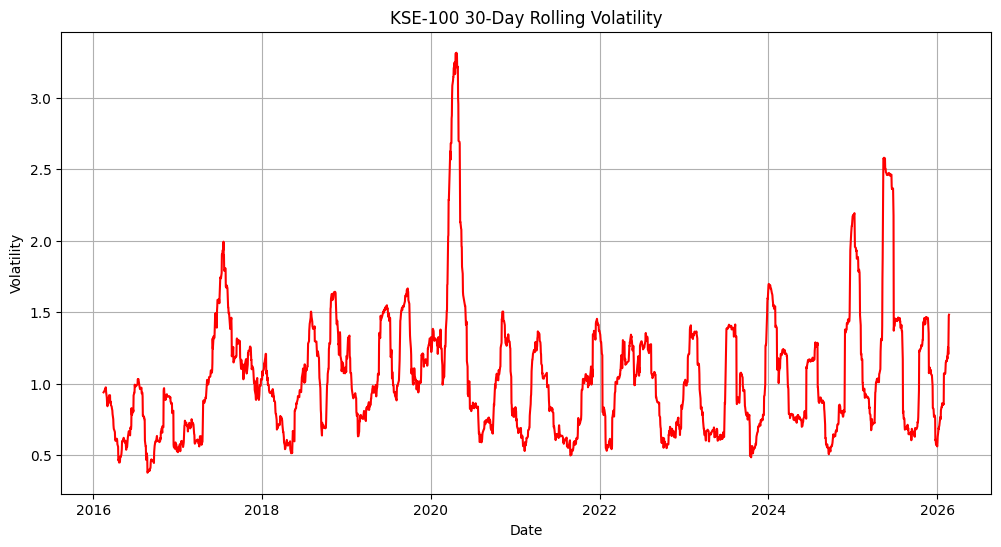

In [ ]:
# 1. Plot the Price Trend
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Price'], label='KSE-100 Price')
plt.title('KSE-100 Index Historical Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# 2. Daily Returns
df['Daily_Return'] = df['Price'].pct_change() * 100
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Daily_Return'], label='Daily Return %', color='orange')
plt.title('KSE-100 Daily Returns (%)')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.grid(True)
plt.show()

# 3. Stationarity Test (ADF)
result = adfuller(df['Price'].dropna())
print(f'\nADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

# 4. ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['Price'].dropna(), ax=ax1, lags=50)
plot_pacf(df['Price'].dropna(), ax=ax2, lags=50)
plt.tight_layout()
plt.show()

# 5. Volatility (Rolling Standard Deviation)
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Volatility_30d'], label='30-day Volatility', color='red')
plt.title('KSE-100 30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.show()

df.to_csv('Cleaned_Karachi_100_Data.csv', index=False)

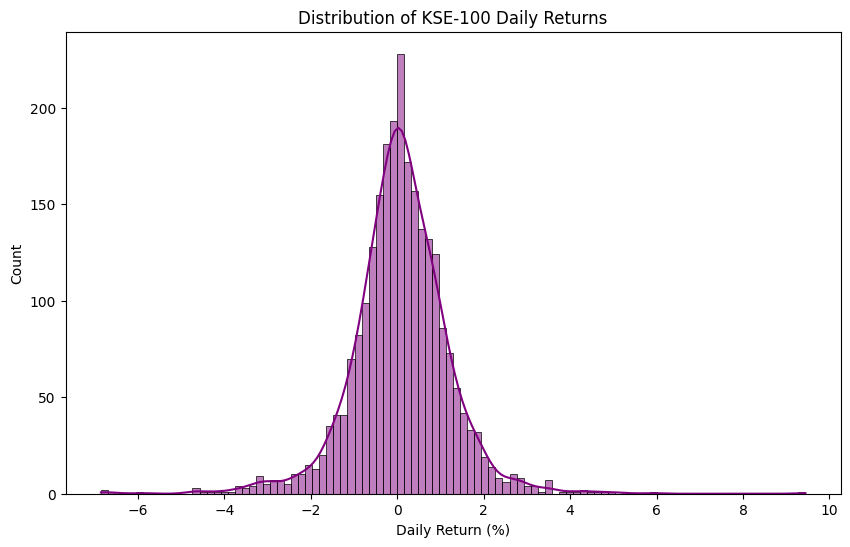


Number of missing business days: 132


/tmp/ipython-input-255/621406148.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_resampled = df.set_index('Date')['Price'].resample('W').mean().fillna(method='ffill')


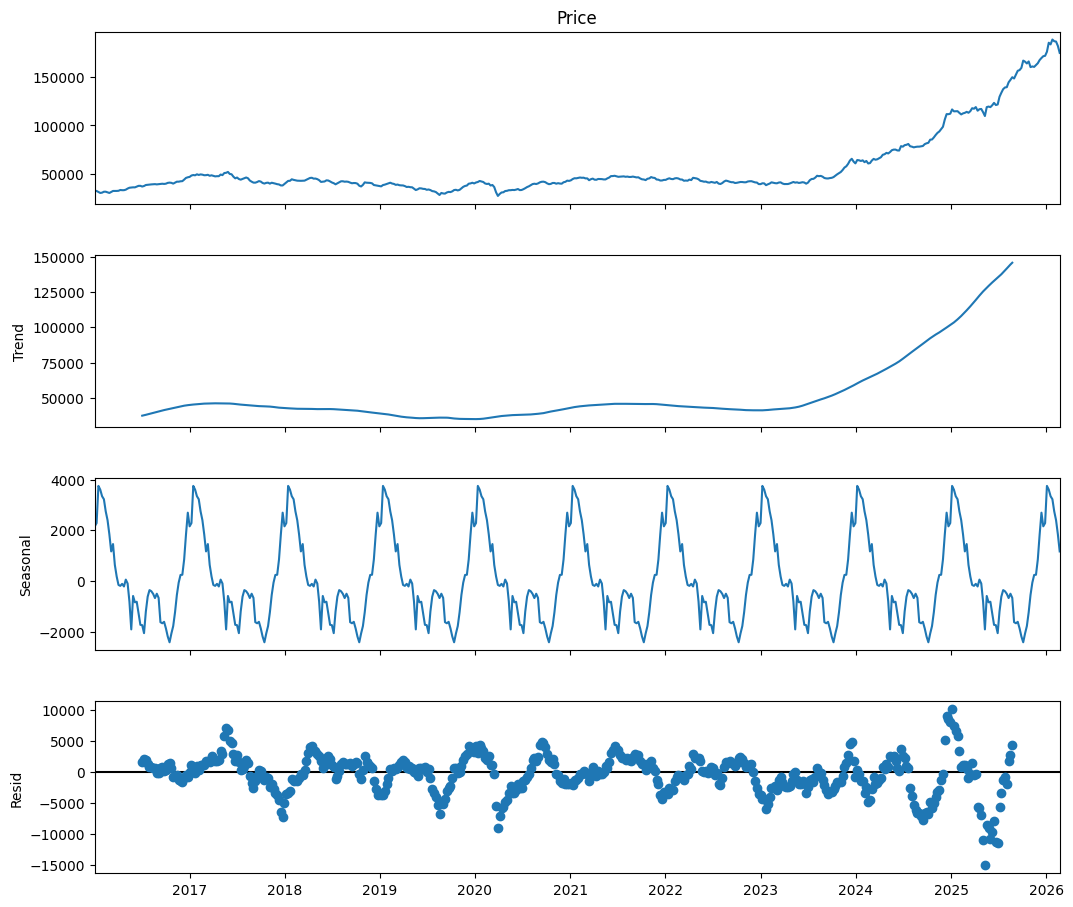


Correlation Matrix:
                 Price      Vol.  Daily_Return
Price         1.000000  0.765485      0.057379
Vol.          0.765485  1.000000      0.141721
Daily_Return  0.057379  0.141721      1.000000


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Distribution of Daily Returns
plt.figure(figsize=(10, 6))
sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True, color='purple')
plt.title('Distribution of KSE-100 Daily Returns')
plt.xlabel('Daily Return (%)')
plt.show()

# 2. Check for missing business days
# Assuming 5-day work week
all_business_days = pd.bdate_range(start=df['Date'].min(), end=df['Date'].max())
missing_days = all_business_days.difference(df['Date'])
print(f"\nNumber of missing business days: {len(missing_days)}")

# 3. Seasonal Decomposition (Monthly trend)
# Resample to weekly to make it smoother and handle gaps
df_resampled = df.set_index('Date')['Price'].resample('W').mean().fillna(method='ffill')
decomposition = seasonal_decompose(df_resampled, model='additive', period=52) # 52 weeks in a year

fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

# 4. Correlation with Volume (where available)
vol_corr = df[['Price', 'Vol.', 'Daily_Return']].corr()
print("\nCorrelation Matrix:")
print(vol_corr)